In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import pandas as pd
test_df = pd.read_csv('/content/drive/My Drive/Data/Capstone/test.csv')
train_df = pd.read_csv('/content/drive/My Drive/Data/Capstone/train.csv')
bts_df = pd.read_csv('/content/drive/My Drive/Data/Capstone/bts_data.csv')

In [28]:
test_df.info()
train_df.info()
bts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date                  275 non-null    object
 1   Region                275 non-null    object
 2   Brand                 275 non-null    object
 3   Model                 275 non-null    object
 4   Vehicle_Type          275 non-null    object
 5   Battery_Capacity_kWh  275 non-null    int64 
 6   Discount_Percentage   275 non-null    int64 
 7   Customer_Segment      275 non-null    object
 8   Fast_Charging_Option  275 non-null    object
dtypes: int64(2), object(7)
memory usage: 19.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 531 entries, 0 to 530
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date                  531 non-null    object
 1   Region                531 non-null 

In [29]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# **Train.csv**

In [30]:
df = train_df.dropna()

df = df.select_dtypes(include=['number'])

In [31]:
X = df.drop(columns=[df.columns[-1]])
y = df[df.columns[-1]]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
# model 1: linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MAE:", mae_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression MAE: 757481.258223868
Linear Regression R2: 0.8392342375774808


In [34]:
# model 2: random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 630960.4760996884
Random Forest R2: 0.8280140110091561


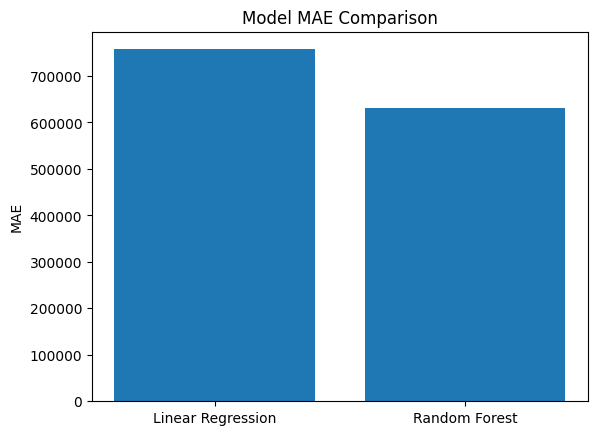

In [35]:
# visual
import matplotlib.pyplot as plt

models = ['Linear Regression', 'Random Forest']
mae_scores = [mae_lr, mae_rf]

plt.bar(models, mae_scores)
plt.title("Model MAE Comparison")
plt.ylabel("MAE")
plt.show()

In [36]:
# comparing models
print("\nModel Comparison:")
print("Linear Regression - MAE:", mae_lr, "R2:", r2_lr)
print("Random Forest - MAE:", mae_rf, "R2:", r2_rf)


Model Comparison:
Linear Regression - MAE: 757481.258223868 R2: 0.8392342375774808
Random Forest - MAE: 630960.4760996884 R2: 0.8280140110091561


demand features

In [37]:
import pandas as pd

train_df = train_df.dropna()

train_df['Date'] = pd.to_datetime(train_df['Date'])

train_df['year'] = train_df['Date'].dt.year
train_df['month'] = train_df['Date'].dt.month

In [38]:
train_df['Brand_Code'] = train_df['Brand'].astype('category').cat.codes

brand_legend = dict(enumerate(train_df['Brand'].astype('category').cat.categories))

print("Brand Legend:")
for k, v in brand_legend.items():
    print(f"{k}: {v}")

Brand Legend:
0: BMW
1: BYD
2: Ford
3: Hyundai
4: Kia
5: Nissan
6: Tesla
7: Toyota
8: Volkswagen


In [39]:
train_df.columns

Index(['Date', 'Region', 'Brand', 'Model', 'Vehicle_Type',
       'Battery_Capacity_kWh', 'Discount_Percentage', 'Customer_Segment',
       'Fast_Charging_Option', 'Units_Sold', 'Revenue', 'year', 'month',
       'Brand_Code'],
      dtype='object')

In [40]:
X = train_df.drop(columns=[
    'Units_Sold',
    'Date',
    'Brand',
    'Model',
    'Vehicle_Type',
    'Customer_Segment',
    'Fast_Charging_Option'
], errors='ignore')

y = train_df['Units_Sold']

In [41]:
X = X.select_dtypes(include=['number'])

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
# model 1: linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MAE:", mae_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression MAE: 37.720277220837026
Linear Regression R2: 0.8036580632745639


In [44]:
# model 2: random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 21.446728971962614
Random Forest R2: 0.9165413222040135


In [45]:
# model comapre
print("\nModel Comparison:")
print("Linear Regression -> MAE:", mae_lr, "| R2:", r2_lr)
print("Random Forest     -> MAE:", mae_rf, "| R2:", r2_rf)


Model Comparison:
Linear Regression -> MAE: 37.720277220837026 | R2: 0.8036580632745639
Random Forest     -> MAE: 21.446728971962614 | R2: 0.9165413222040135


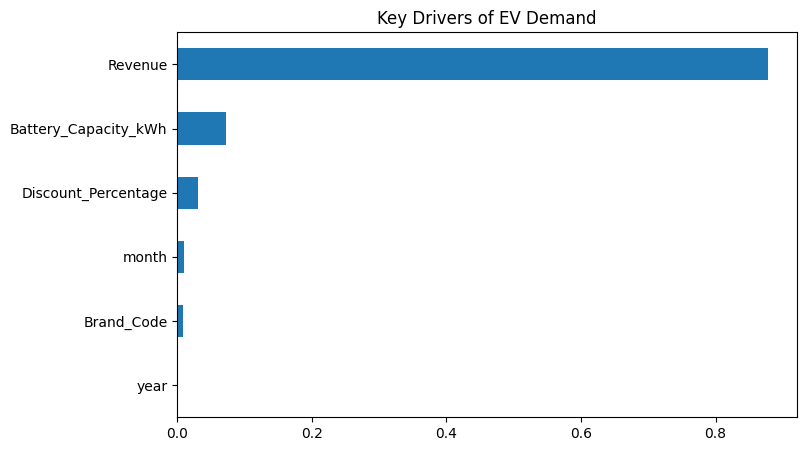

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Key Drivers of EV Demand")
plt.show()

time demand

In [47]:
train_df['Date'] = pd.to_datetime(train_df['Date'], format='%Y-%m')

In [48]:
monthly_demand = train_df.groupby('Date')['Units_Sold'].sum().reset_index()

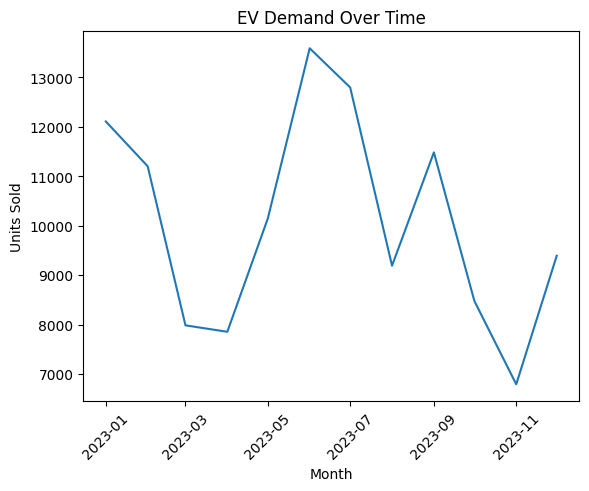

In [49]:
import matplotlib.pyplot as plt

plt.plot(monthly_demand['Date'], monthly_demand['Units_Sold'])
plt.title("EV Demand Over Time")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()

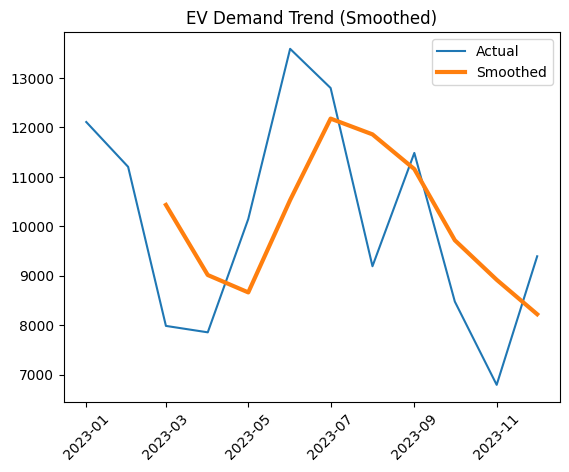

In [50]:
monthly_demand['rolling_avg'] = monthly_demand['Units_Sold'].rolling(3).mean()

plt.plot(monthly_demand['Date'], monthly_demand['Units_Sold'], label='Actual')
plt.plot(monthly_demand['Date'], monthly_demand['rolling_avg'], label='Smoothed', linewidth=3)

plt.title("EV Demand Trend (Smoothed)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

# **Results**

Demand Insights

Results: Demand for EV is flucuating but increasing.

Findings:

- Key driver for demand is revenue
- Demand dropped in 2023 but is increasing again
- Models (linear regression and random forest) fits the observed data well